# N-variable, M-output L.R. (Keras)

## Load modules

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :2.0.2
TensorFlow Version :2.19.0
Matplotlib Version :3.10.0


## Input and Label

In [2]:
#Input(AGE, BMI) and Labels(HIGH, LOW)
x_input = tf.constant([[25,22],[25,26],[25,30],[35,22],[35,26],[35,30],[45,22],[45,26],[45,30],[55,22],[55,26],[55,30],[65,22],[65,26],[65,30],[73,22],[73,26],[73,30]], dtype= tf.float32)
labels = tf.constant([[118,72],[125,80],[130,80],[118,76],[126,75],[123,79],[120,80],[124,85],[130,83],[122,78],[125,80],[130,81],[127,75],[130,79],[130,81],[125.5,80],[130,80],[138,82]], dtype= tf.float32)

## Min Max Scaler

In [3]:
x_input_org = x_input
x_min, x_max = np.min(x_input, axis=0), np.max(x_input, axis=0)
x_input = (x_input-x_min)/(x_max-x_min)

## Model 정의

In [4]:
model = tf.keras.models.Sequential([
  tf.keras.Input(shape=(2,)),
  tf.keras.layers.Dense(2)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (24.00 B)

 Trainable params: 6 (24.00 B)

 Non-trainable params: 0 (0.00 B)

## Model compile

In [5]:
model.compile(optimizer= tf.keras.optimizers.SGD(learning_rate=0.1), loss='mean_squared_error')

## 학습 (Training)

In [ ]:
%%time
history = model.fit(x_input, labels, epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - loss: 11027.5918
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 7920.6816
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 5709.1191
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 4134.5112
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3013.0420
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2213.9502
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 1644.2148
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1237.6626
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 947.2190
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 739.3959
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 590.3707
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 483.1955
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 405.8140
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 349.6491
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━

## Plot

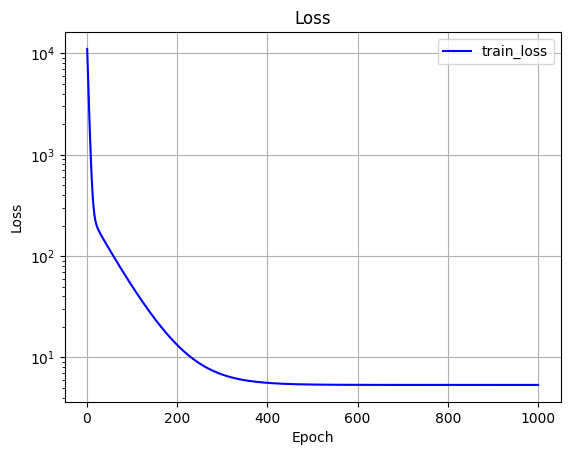

In [ ]:
# loss 그래프 출력
loss = history.history['loss']
epochs = range(1, len(loss)+1)
plt.title('Loss')
plt.plot(epochs, history.history['loss'], 'b', label='train_loss')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.semilogy()
plt.show()

## Training 결과 Test

In [ ]:
H_x = model.predict(x_input)
for x,h,l in zip(x_input_org, H_x, labels):
  print("Age:{}, BMI:{}=>BP:{:>7.4},{:>7.4} [label => {}]".format(x[0],x[1],h[0], h[1],l))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Age:25.0, BMI:22.0=>BP:  118.0,  75.78 [label => [118.  72.]]
Age:25.0, BMI:26.0=>BP:  122.2,  77.87 [label => [125.  80.]]
Age:25.0, BMI:30.0=>BP:  126.4,  79.95 [label => [130.  80.]]
Age:35.0, BMI:22.0=>BP:  119.6,  76.33 [label => [118.  76.]]
Age:35.0, BMI:26.0=>BP:  123.8,  78.42 [label => [126.  75.]]
Age:35.0, BMI:30.0=>BP:  128.0,   80.5 [label => [123.  79.]]
Age:45.0, BMI:22.0=>BP:  121.2,  76.88 [label => [120.  80.]]
Age:45.0, BMI:26.0=>BP:  125.4,  78.97 [label => [124.  85.]]
Age:45.0, BMI:30.0=>BP:  129.7,  81.05 [label => [130.  83.]]
Age:55.0, BMI:22.0=>BP:  122.8,  77.43 [label => [122.  78.]]
Age:55.0, BMI:26.0=>BP:  127.1,  79.51 [label => [125.  80.]]
Age:55.0, BMI:30.0=>BP:  131.3,   81.6 [label => [130.  81.]]
Age:65.0, BMI:22.0=>BP:  124.5,  77.98 [label => [127.  75.]]
Age:65.0, BMI:26.0=>BP:  128.7,  80.06 [label => [130.  79.]]
Age:65.0, BMI:30.0=>BP:  132.9,  82.15 [label => [130.  81.]]
Age:73.0, BMI:22.0=>BP:  125.7, 

## Predict

In [ ]:
def predict(x):
  return model.predict((x-x_min)/(x_max-x_min))

In [ ]:
x_test = tf.constant([[50.0, 25.0]], dtype= tf.float32)
H_x = predict(x_test)
print("Age : {}, BMI : {} = > BP : {:>7.4}, {:>7.4}".format(x_test[0,0],x_test[0,1],H_x[0,0],H_x[0,1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Age : 50.0, BMI : 25.0 = > BP :   125.2,   78.72
